# LeetCode #81: Search in Rotated Sorted Array II

https://leetcode.com/problems/search-in-rotated-sorted-array-ii/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Optimal: Binary Search with Duplicate Handling ★** | $O(n)$ worst, $O(\log n)$ avg | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Scan every element. Always $O(n)$ — no benefit from sorted or rotated structure.

### Optimal: Binary Search with Duplicate Handling ★
Same pivot-detection logic as #33, but when `nums[lo] == nums[mid]` we cannot determine which half is sorted. The fix is simply `lo++` to skip the ambiguous duplicate; in the worst case (all duplicates) this degrades to $O(n)$, but in practice the algorithm is $O(\log n)$ average.

**Constraints:**
* 1 <= nums.length <= 5000
* -10^4 <= nums[i] <= 10^4
* nums is sorted and rotated (may contain duplicates)
* -10^4 <= target <= 10^4


## Solutions

### C#

In [ ]:
public bool Search(int[] nums, int target) {
    int lo = 0, hi = nums.Length - 1;
    while (lo <= hi) {
        int mid = lo + (hi - lo) / 2;
        if (nums[mid] == target) return true;
        // Can't determine sorted half when boundaries equal mid — skip one duplicate
        if (nums[lo] == nums[mid]) { lo++; continue; }
        if (nums[lo] < nums[mid]) {
            // Left half is sorted
            if (nums[lo] <= target && target < nums[mid]) hi = mid - 1;
            else lo = mid + 1;
        } else {
            // Right half is sorted
            if (nums[mid] < target && target <= nums[hi]) lo = mid + 1;
            else hi = mid - 1;
        }
    }
    return false;
}


### Python

In [ ]:
def search(self, nums: list[int], target: int) -> bool:
    lo, hi = 0, len(nums) - 1
    while lo <= hi:
        mid = lo + (hi - lo) // 2
        if nums[mid] == target:
            return True
        # Can't determine sorted half when boundaries equal mid — skip one duplicate
        if nums[lo] == nums[mid]:
            lo += 1
            continue
        if nums[lo] < nums[mid]:
            # Left half is sorted
            if nums[lo] <= target < nums[mid]:
                hi = mid - 1
            else:
                lo = mid + 1
        else:
            # Right half is sorted
            if nums[mid] < target <= nums[hi]:
                lo = mid + 1
            else:
                hi = mid - 1
    return False


### Go

In [ ]:
func search(nums []int, target int) bool {
    lo, hi := 0, len(nums)-1
    for lo <= hi {
        mid := lo + (hi-lo)/2
        if nums[mid] == target {
            return true
        }
        // Can't determine sorted half when boundaries equal mid — skip one duplicate
        if nums[lo] == nums[mid] {
            lo++
            continue
        }
        if nums[lo] < nums[mid] {
            // Left half is sorted
            if nums[lo] <= target && target < nums[mid] {
                hi = mid - 1
            } else {
                lo = mid + 1
            }
        } else {
            // Right half is sorted
            if nums[mid] < target && target <= nums[hi] {
                lo = mid + 1
            } else {
                hi = mid - 1
            }
        }
    }
    return false
}


### Rust

In [ ]:
pub fn search(nums: Vec<i32>, target: i32) -> bool {
    let (mut lo, mut hi) = (0i32, nums.len() as i32 - 1);
    while lo <= hi {
        let mid = lo + (hi - lo) / 2;
        if nums[mid as usize] == target { return true; }
        // Can't determine sorted half when boundaries equal mid — skip one duplicate
        if nums[lo as usize] == nums[mid as usize] { lo += 1; continue; }
        if nums[lo as usize] < nums[mid as usize] {
            // Left half is sorted
            if nums[lo as usize] <= target && target < nums[mid as usize] {
                hi = mid - 1;
            } else {
                lo = mid + 1;
            }
        } else {
            // Right half is sorted
            if nums[mid as usize] < target && target <= nums[hi as usize] {
                lo = mid + 1;
            } else {
                hi = mid - 1;
            }
        }
    }
    false
}


## Example Scenarios

**1. Common Case**
**Input:** nums = [2, 5, 6, 0, 0, 1, 2], target = 0
mid=3, val=0 → return true immediately. Pivot detection not even needed — target found at first mid.

**2. Slightly Complex**
**Input:** nums = [2, 5, 6, 0, 0, 1, 2], target = 3
mid=3(0): nums[lo]=2 ≠ nums[mid]=0 → right sorted [0..2]; 3 ∉ (0,2] → hi=2. mid=1(5): left sorted [2..5]; 3 ∉ [2,5) → lo=2. mid=2(6) > 3 → hi=1. lo>hi → false.

**3. Edge Case: Time Factor**
**Input:** nums = [1, 1, 1, ..., 1, 0] (4999 ones then 0), target = 0
Every iteration hits `nums[lo]==nums[mid]` → lo++ until lo reaches index 4999 where 0 is found. This is the $O(n)$ worst case caused by uniform duplicates masking the pivot location.

**4. Edge Case: Space Factor**
**Input:** nums = [1], target = 1
Single element: lo=hi=0, mid=0, val=1=target → true. $O(1)$ space regardless — no recursion, no extra arrays.

**5. Almost-Impossible but Plausible**
**Input:** nums = [3, 3, 3, 3, 1, 3], target = 1
mid=2(3): nums[lo]=3=nums[mid] → lo++. mid=2(3) again: lo++. mid=2(3): lo++. Now lo=3, hi=5, mid=4(1)=target → true. The duplicate-skip (`lo++`) correctly escapes the ambiguous region, found after $O(n/2)$ steps in this near-worst-case distribution.


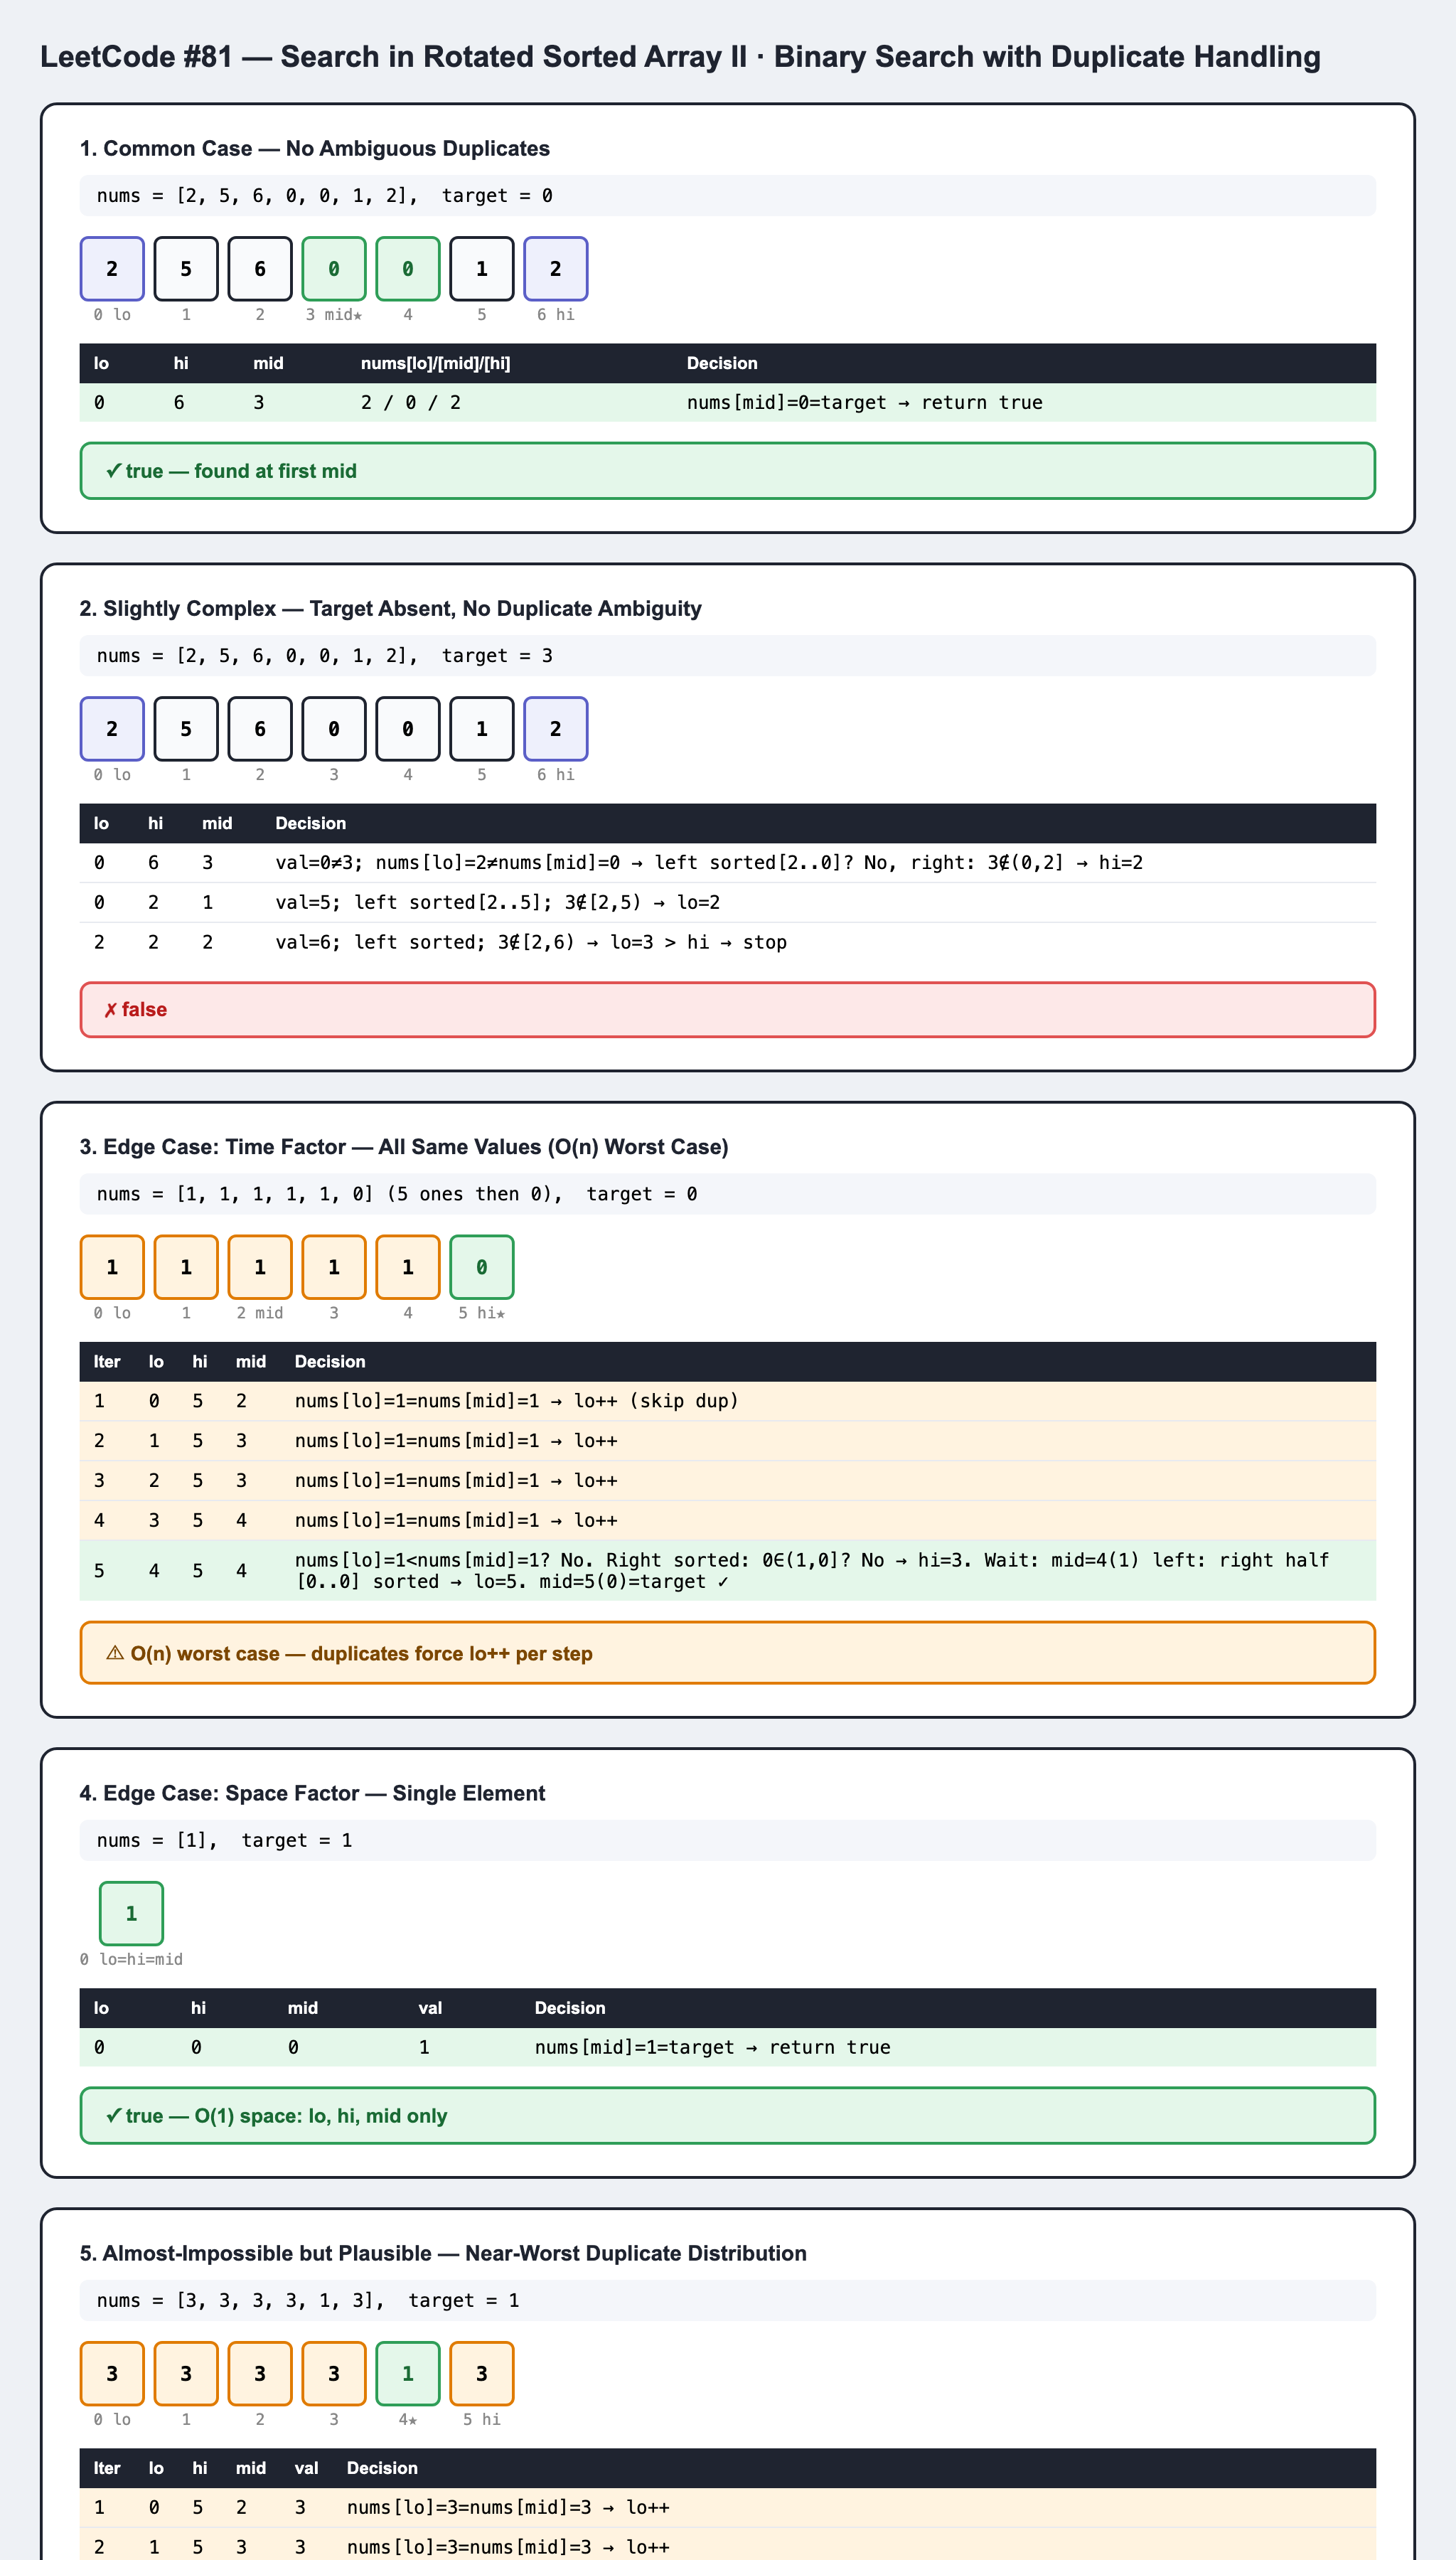